In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(1)') 

array([2], dtype=int64)

In [13]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("setting.jl")
Main.include("core\\constants.jl")
Main.include("core\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\FO.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

Plot

In [18]:
xlist = np.pi/180*np.linspace(1.0, 30, 100, endpoint=True)
length=len(xlist)

v={}
non_singular_LO = []
non_singular_NLO = []
non_singular_NNLO = []

for x in xlist:
    Main.eval(f'@everywhere αs_Z = {0.118}')
    Main.eval(f'@everywhere μren_ratio = 0.5')

    Main.nloops_NS_bulk = 2
    Main.nloops_NS_peak = 1

    non_singular_LO.append(Main.non_singular_sigma_χ(χ=x, Q=91.2))

    Main.nloops_NS_bulk = 1
    Main.nloops_NS_peak = 1

    non_singular_NLO.append(Main.non_singular_sigma_χ(χ=x, Q=91.2))

    Main.nloops_NS_bulk = 0
    Main.nloops_NS_peak = 0

    non_singular_NNLO.append(Main.non_singular_sigma_χ(χ=x, Q=91.2))

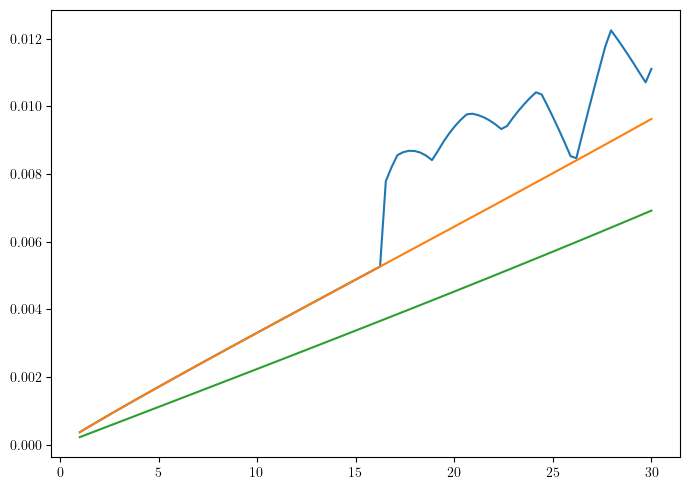

In [19]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

ax1.plot(xlist*180/np.pi, non_singular_LO)
ax1.plot(xlist*180/np.pi, non_singular_NLO)
ax1.plot(xlist*180/np.pi, non_singular_NNLO)

plt.tight_layout()  
plt.show()